# Taller 1 - Regresión: tarifa de viajes de Uber en Nueva York (2009–2015)

**Dataset:** *Uber Ride Price Prediction* (Kaggle) - 200.000 viajes registrados entre el
1 de enero de 2009 y el 30 de junio de 2015 en el área metropolitana de Nueva York.

**Target:** `fare_amount`, tarifa cobrada en dólares estadounidenses (variable continua).

## Fase 1 - EDA, limpieza y preprocesamiento

### 1. Problema de negocio, dataset y variable objetivo

Uber cobra al usuario una tarifa que depende de la distancia recorrida, del tiempo del
viaje y de la demanda. Este CSV contiene viajes individuales con origen y destino (GPS),
fecha y hora de recogida, número de pasajeros y la tarifa final cobrada.

- **Problema de negocio:** estimar la tarifa esperada de un viaje antes de completarlo
  (cotización al usuario) y detectar tarifas atípicas que no se explican por las
  características del viaje.
- **Variable objetivo:** `fare_amount`, continua y expresada en USD, es un problema de
  **regresión**.
- **Alcance del modelo:** aprende la relación histórica entre atributos observables del
  viaje y tarifa. El dataset **no** incluye variables de demanda ni multiplicadores de
  *surge pricing*, por lo que la demanda solo puede capturarse indirectamente a través de
  la hora y la fecha. Tampoco se debe leer como la política tarifaria actual de Uber: los
  datos terminan en junio de 2015.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

candidatos = [Path("data/raw/uber/uber.csv"), Path("../data/raw/uber/uber.csv")]
DATA_PATH = next(p for p in candidatos if p.exists())
print("Archivo (relativo a la raíz del repo):", DATA_PATH)

Archivo (relativo a la raíz del repo): ../data/raw/uber/uber.csv


### 2. Carga, estructura y diccionario de datos

Se carga el CSV original sin modificarlo (la limpieza se hace en memoria y queda
justificada más abajo). Se revisan `head()`, `tail()`, `.shape` y `.info()`.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
display(df_raw.head(3))
display(df_raw.tail(3))
print("shape:", df_raw.shape)
df_raw.info()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5000,2015-05-07 19:52:06 UTC,-73.9998,40.7384,-73.9995,40.7232,1
1,27835199,04:56.0,7.7000,2009-07-17 20:04:56 UTC,-73.9944,40.7282,-73.9947,40.7503,1
2,44984355,45:00.0,12.9000,2009-08-24 21:45:00 UTC,-74.0050,40.7408,-73.9626,40.7726,1


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199997,27804658,42:00.0,30.9000,2009-06-29 00:42:00 UTC,-73.9860,40.7565,-73.8590,40.6926,2
199998,20259894,56:25.0,14.5000,2015-05-20 14:56:25 UTC,-73.9971,40.7255,-73.9832,40.6954,1
199999,11951496,08:00.0,14.1000,2010-05-15 04:08:00 UTC,-73.9844,40.7201,-73.9855,40.7688,1


shape: (200000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


El CSV tiene 9 columnas y 200.000 filas. Todas son numéricas salvo `key` y
`pickup_datetime`. El diccionario de datos documenta el significado de cada columna y su
uso previsto:

In [4]:
diccionario = pd.DataFrame([
    ("Unnamed: 0", "int64", "Consecutivo exportado por el CSV; 200.000 valores únicos.", "Excluir: es un índice heredado, no un atributo del viaje."),
    ("key", "object", "Identificador anonimizado truncado con formato MM:SS.d; solo 3.600 valores repetidos.", "Excluir: no describe el viaje ni generaliza a datos nuevos."),
    ("fare_amount", "float64", "Tarifa cobrada por el viaje en USD.", "Target (y)."),
    ("pickup_datetime", "object (UTC)", "Fecha y hora de recogida, formato ISO de 23 caracteres.", "Parsear a datetime UTC; base de hour, day_of_week, month y year."),
    ("pickup_longitude", "float64", "Longitud del origen (WGS84).", "Usar en Haversine y validación geográfica; excluir después."),
    ("pickup_latitude", "float64", "Latitud del origen (WGS84).", "Usar en Haversine y validación geográfica; excluir después."),
    ("dropoff_longitude", "float64", "Longitud del destino (WGS84). 1 nulo.", "Usar en Haversine y validación geográfica; excluir después."),
    ("dropoff_latitude", "float64", "Latitud del destino (WGS84). 1 nulo.", "Usar en Haversine y validación geográfica; excluir después."),
    ("passenger_count", "int64", "Pasajeros declarados. Válidos 1–6; 0 y 208 son códigos inválidos.", "Convertir inválidos a NaN y tratarla como categórica."),
], columns=["columna", "tipo_esperado", "significado", "uso_previsto"])
display(diccionario)

,columna,tipo_esperado,significado,uso_previsto
0,Unnamed: 0,int64,Consecutivo exportado por el CSV; 200.000 valo...,"Excluir: es un índice heredado, no un atributo..."
1,key,object,Identificador anonimizado truncado con formato...,Excluir: no describe el viaje ni generaliza a ...
2,fare_amount,float64,Tarifa cobrada por el viaje en USD.,Target (y).
3,pickup_datetime,object (UTC),"Fecha y hora de recogida, formato ISO de 23 ca...","Parsear a datetime UTC; base de hour, day_of_w..."
4,pickup_longitude,float64,Longitud del origen (WGS84).,Usar en Haversine y validación geográfica; exc...
5,pickup_latitude,float64,Latitud del origen (WGS84).,Usar en Haversine y validación geográfica; exc...
6,dropoff_longitude,float64,Longitud del destino (WGS84). 1 nulo.,Usar en Haversine y validación geográfica; exc...
7,dropoff_latitude,float64,Latitud del destino (WGS84). 1 nulo.,Usar en Haversine y validación geográfica; exc...
8,passenger_count,int64,Pasajeros declarados. Válidos 1–6; 0 y 208 son...,Convertir inválidos a NaN y tratarla como cate...


De las 9 columnas, dos (`Unnamed: 0` y `key`) no aportan información sobre el viaje y se
excluirán. Las cuatro coordenadas se usan para construir la distancia y luego se
eliminan para no duplicar la misma señal geográfica; la tarifa se separa como `y`.

### 3. Estudio numérico con `.describe()` e interpretación

Se describe el conjunto numérico excluyendo `Unnamed: 0`, porque es un índice sin
significado analítico y sus estadísticas (media de 27,7 millones) no representan nada del
viaje.

In [5]:
desc = df_raw.drop(columns=["Unnamed: 0"]).describe().T
display(desc)
display(df_raw.drop(columns=["Unnamed: 0"]).skew(numeric_only=True).rename("asimetria").to_frame())

,count,mean,std,min,25%,50%,75%,max
fare_amount,"200,000.0000",11.3600,9.9018,-52.0000,6.0000,8.5000,12.5000,499.0000
pickup_longitude,"200,000.0000",-72.5276,11.4378,"-1,340.6484",-73.9921,-73.9818,-73.9672,57.4185
pickup_latitude,"200,000.0000",39.9359,7.7205,-74.0155,40.7348,40.7526,40.7672,"1,644.4215"
dropoff_longitude,"199,999.0000",-72.5253,13.1174,"-3,356.6663",-73.9914,-73.9801,-73.9637,"1,153.5726"
dropoff_latitude,"199,999.0000",39.9239,6.7948,-881.9855,40.7338,40.7530,40.7680,872.6976
passenger_count,"200,000.0000",1.6845,1.3860,0.0000,1.0000,1.0000,2.0000,208.0000


,asimetria
fare_amount,4.5048
pickup_longitude,-7.4959
pickup_latitude,62.9769
dropoff_longitude,-71.5051
dropoff_latitude,-8.0310
passenger_count,18.1455


**Lectura de los estadísticos (raw data):**

1. **`fare_amount`: media 11,36 USD vs. mediana 8,50 USD, desviación 9,90 y máximo 499.**
   La media supera a la mediana porque la distribución tiene cola derecha (asimetría
   4,50). El viaje típico cuesta 8,50 USD, pero unos pocos viajes largos o a aeropuerto
   inflan el promedio.
2. **`fare_amount` tiene mínimo −52 USD.** Un precio negativo no es una tarifa: son
   reversos o ajustes contables. Contaminan el target y deben excluirse en el apartado de ingeniería de variables.
3. **`passenger_count`: media 1,68, mediana 1 y máximo 208.** La mitad de los viajes
   lleva un pasajero y la media se ve arrastrada por valores imposibles: 709 registros
   con 0 pasajeros (un viaje sin pasajeros no existe) y uno con 208. Son errores de
   captura, no ocupaciones reales; se convierten a NaN.
4. **Coordenadas:** la longitud de recogida va de −1340,65 a 57,42 y la latitud hasta
   1644,42, cuando Nueva York está alrededor de (−74, 40,7). Esos extremos son
   imposibles y obligan a una validación geográfica antes de calcular distancias.

### 4. Valores nulos y estrategia de imputación

Se calcula el número y el porcentaje de nulos por columna y se revisa a qué fila
pertenecen.

In [6]:
nulos = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "porcentaje": (100 * df_raw.isna().mean()).round(4),
})
display(nulos[nulos["nulos"] > 0])
display(df_raw[df_raw.isna().any(axis=1)])

,nulos,porcentaje
dropoff_longitude,1,0.0005
dropoff_latitude,1,0.0005


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,51:57.0,24.1000,2013-07-02 03:51:57 UTC,-73.9506,40.7797,NaN,NaN,0


Solo hay 2 celdas nulas: `dropoff_longitude` y `dropoff_latitude`, 1 cada una
(0,0005 %) y pertenecen a la misma fila (índice 87946). Esa fila tiene tarifa 24,10 USD,
origen válido en Nueva York y `passenger_count = 0` (también inválido).

Evaluación de las tres estrategias posibles:

- **Imputar las coordenadas con la mediana:** inaceptable. Las coordenadas no faltan al
  azar; se perdió el destino y reemplazarlo por la mediana de Manhattan inventaría un
  viaje que no ocurrió. Además ya usamos la mediana para otra variable; imputar GPS con
  un único punto central sesgaría cualquier distancia.
- **Imputar `trip_distance_km` con la mediana:** tampoco. Para un viaje de 24,10 USD a
  las 03:51 probablemente largo, asignarle la distancia mediana (~2,2 km) crea una
  observación falsa en la variable más predictiva.
- **Eliminar la fila:** es la opción más viable. Al no poder validar el destino ni
  calcular la distancia, la fila no puede aportar una observación completa. Coste:
  1 de 200.000 filas (0,0005 %). La fila queda además cubierta por el filtro geográfico
  del apartado de ingeniería de variables (un extremo nulo no puede estar dentro de la caja NYC).

**Decisión:** excluir esa fila mediante el filtro geográfico y mantener el
`SimpleImputer` dentro del pipeline como salvaguarda para datos futuros. El imputador
que sí trabaja con los datos actuales es el categórico, que rellena los 687
`passenger_count` inválidos (0,35 % de las filas limpias) con la moda, que en esta
variable es 1 (el mismo valor que daría la mediana porque los pasajeros son enteros).
No se creó una categoría "desconocido" porque representaría 0,35 % de las filas y
fragmentaría una señal que, por lo demás, es secundaria frente a la distancia.

### 5. Duplicados

In [7]:
print("Duplicados exactos:", df_raw.duplicated().sum())
print("Duplicados ignorando el índice del CSV:", df_raw.drop(columns=["Unnamed: 0"]).duplicated().sum())
print("Timestamps repetidos (no es duplicación de filas):", df_raw["pickup_datetime"].duplicated().sum())

Duplicados exactos: 0
Duplicados ignorando el índice del CSV: 0
Timestamps repetidos (no es duplicación de filas): 3371


No se encontró **ningún duplicado exacto** (0 filas eliminadas). También se verificó que
al ignorar `Unnamed: 0` siguen siendo 0, es decir, no hay viajes repetidos con distinto
consecutivo. Los 3.371 timestamps repetidos son esperables: varios viajes pueden empezar
en el mismo segundo en una ciudad del tamaño de Nueva York y no implican duplicación.

### 6. Revisión de formato en columnas de texto

In [8]:
chequeo = []
for col in df_raw.select_dtypes(include=["object", "string"]).columns:
    s = df_raw[col].astype(str)
    chequeo.append({
        "columna": col,
        "niveles": df_raw[col].nunique(),
        "espacios_extremos": int((s != s.str.strip()).sum()),
        "niveles_tras_strip": s.str.strip().nunique(),
        "niveles_tras_minusculas": s.str.lower().nunique(),
    })
display(pd.DataFrame(chequeo))

print("key con formato MM:SS.d:", df_raw["key"].astype(str).str.fullmatch(r"\d{2}:\d{2}\.\d").mean())
print("fechas no parseables:", pd.to_datetime(df_raw["pickup_datetime"], utc=True, errors="coerce").isna().sum())

,columna,niveles,espacios_extremos,niveles_tras_strip,niveles_tras_minusculas
0,key,3600,0,3600,3600
1,pickup_datetime,196629,0,196629,196629


key con formato MM:SS.d: 1.0
fechas no parseables: 0


Cero espacios sobrantes y cero diferencias de mayúsculas equivalentes. Las
dos columnas de texto son un identificador (`key`, con un formato uniforme de 7
caracteres) y una fecha ISO uniforme de 23 caracteres que parsea sin errores. Es decir,
no hay etiquetas equivalentes que unificar; se documenta la verificación y no se
inventan cambios. Las verdaderas variables categóricas del modelo (`hour`,
`day_of_week`, `month`, `year`) se derivan de la fecha y son internamente consistentes.

### Ingeniería de variables y filtro geográfico (soporte de los puntos 4, 6 y 7)

Con el formato validado, se construyen las variables de trabajo:

1. `pickup_datetime` se convierte a datetime UTC y se derivan `hour`, `day_of_week`,
   `month` y `year` (categóricas de baja cardinalidad; justificación en el punto 9, codificación).
2. Los `passenger_count` inválidos (0 y 208) pasan a NaN.
3. Se excluyen las tarifas no positivas.
4. Se valida que los cuatro puntos extremos del viaje estén dentro de una caja
   geográfica que cubre el área urbana y los aeropuertos (LGA, JFK y márgenes de EWR):
   longitud [−74,3, −73,6] y latitud [40,4, 41,0].
5. Se calcula `trip_distance_km` con la fórmula de Haversine y se descartan las
   coordenadas crudas.

Primero la fecha, los inválidos de ocupación y las tarifas no positivas:

In [9]:
df = df_raw.copy()
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], utc=True, errors="coerce")
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["month"] = df["pickup_datetime"].dt.month
df["year"] = df["pickup_datetime"].dt.year

incompletas_fecha = df["hour"].isna().sum()
sin_pasajeros_validos = ~df["passenger_count"].between(1, 6)
n_pasajeros_invalidos = int(sin_pasajeros_validos.sum())
df.loc[sin_pasajeros_validos, "passenger_count"] = np.nan

tarifas_no_positivas = df["fare_amount"] <= 0
print("Fechas no convertibles:", incompletas_fecha)
print("Filas con passenger_count inválido (raw):", n_pasajeros_invalidos)
print("Filas con fare_amount <= 0:", int(tarifas_no_positivas.sum()))
display(df.loc[tarifas_no_positivas, "fare_amount"].sort_values().to_frame().T)

df = df.loc[~tarifas_no_positivas].copy()
print("Filas tras excluir tarifas no positivas:", len(df))

Fechas no convertibles: 0
Filas con passenger_count inválido (raw): 710
Filas con fare_amount <= 0: 22


,111589,98875,164056,89322,92063,151681,104080,139272,148803,190925,63395,79903,157412,179111,71246,150301,180444,22182,20744,87467,156738,197172
fare_amount,-52.0000,-52.0000,-50.5000,-49.5700,-23.7000,-10.9000,-7.3000,-6.9000,-5.7000,-5.5000,-5.0000,-3.5000,-3.5000,-3.5000,-3.3000,-3.0000,-3.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Filas tras excluir tarifas no positivas: 199978


Las tarifas no positivas (22 filas) se eliminan porque el target debe ser un precio: 17
son negativas (entre −52 y −3 USD, compatibles con reversos o ajustes) y 5 son cero. No
es una decisión de outliers sino de validez del target.

Ahora el diagnóstico geográfico. El gráfico muestra los puntos de recogida del archivo
original dentro de la caja; los puntos rojos son los que quedan fuera y justifican el
filtro.

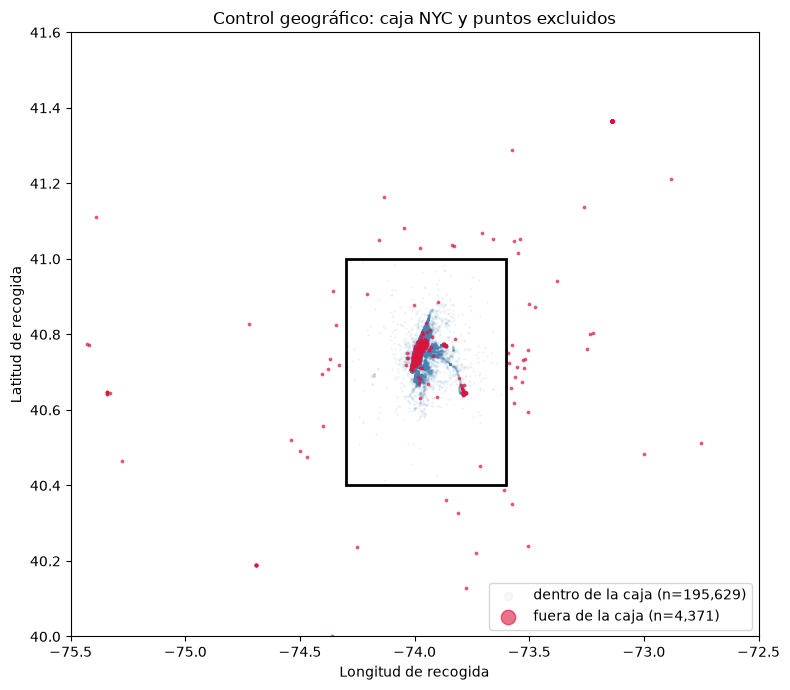

Filas fuera de la caja en el archivo original: 4371 (2.185 %)
Puntos con coordenada exactamente (0,0): 3779 orígenes, 3756 destinos
Filas con un extremo dentro y el otro fuera: 511


In [10]:
b = dict(lon_min=-74.3, lon_max=-73.6, lat_min=40.4, lat_max=41.0)
dentro = (
    df_raw["pickup_longitude"].between(b["lon_min"], b["lon_max"]) &
    df_raw["pickup_latitude"].between(b["lat_min"], b["lat_max"]) &
    df_raw["dropoff_longitude"].between(b["lon_min"], b["lon_max"]) &
    df_raw["dropoff_latitude"].between(b["lat_min"], b["lat_max"])
)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(df_raw.loc[dentro, "pickup_longitude"], df_raw.loc[dentro, "pickup_latitude"],
           s=1, alpha=0.05, color="steelblue", label=f"dentro de la caja (n={int(dentro.sum()):,})")
ax.scatter(df_raw.loc[~dentro, "pickup_longitude"], df_raw.loc[~dentro, "pickup_latitude"],
           s=3, alpha=0.6, color="crimson", label=f"fuera de la caja (n={int((~dentro).sum()):,})")
ax.add_patch(plt.Rectangle((b["lon_min"], b["lat_min"]), b["lon_max"]-b["lon_min"], b["lat_max"]-b["lat_min"],
                           fill=False, edgecolor="black", linewidth=2))
ax.set_xlim(-75.5, -72.5); ax.set_ylim(40.0, 41.6)
ax.set_xlabel("Longitud de recogida"); ax.set_ylabel("Latitud de recogida")
ax.set_title("Control geográfico: caja NYC y puntos excluidos")
ax.legend(loc="lower right", markerscale=6)
plt.tight_layout(); plt.show()

print("Filas fuera de la caja en el archivo original:", int((~dentro).sum()), f"({100*(~dentro).mean():.3f} %)")
print("Puntos con coordenada exactamente (0,0):", int(((df_raw.pickup_longitude==0)&(df_raw.pickup_latitude==0)).sum()), "orígenes,",
      int(((df_raw.dropoff_longitude==0)&(df_raw.dropoff_latitude==0)).sum()), "destinos")
una_punta = ((df_raw.pickup_longitude.between(b["lon_min"], b["lon_max"]) & df_raw.pickup_latitude.between(b["lat_min"], b["lat_max"])) ^
             (df_raw.dropoff_longitude.between(b["lon_min"], b["lon_max"]) & df_raw.dropoff_latitude.between(b["lat_min"], b["lat_max"])))
print("Filas con un extremo dentro y el otro fuera:", int(una_punta.sum()))

**Hallazgo:** 4.371 filas (2,19 %) quedan fuera de la caja NYC. La nube azul se
concentra dentro de Manhattan y los aeropuertos; los puntos rojos bordean la caja (zonas
mal georreferenciadas) y el gráfico recorta los casos más extremos: 3.779 orígenes y
3.756 destinos caen exactamente en (0, 0), una coordenada imposible para un viaje en
Nueva York, y hay longitudes y latitudes de hasta ±3.356. Solo 511 filas tienen un
extremo dentro y el otro fuera; el resto tiene ambos extremos mal capturados.

**Decisión:** excluir esas filas porque son errores de captura GPS, no viajes largos
plausibles. Si se conservaran, la distancia Haversine daría cientos o miles de
kilómetros y el modelo aprendería relaciones espurias. La fila con el destino nulo cae
en este filtro, como se anticipó.

Se aplica el filtro y se calcula la distancia Haversine:

In [11]:
df = df.loc[dentro.loc[df.index]].copy()

R_TIERRA_KM = 6371.0088
lat1 = np.radians(df["pickup_latitude"]); lon1 = np.radians(df["pickup_longitude"])
lat2 = np.radians(df["dropoff_latitude"]); lon2 = np.radians(df["dropoff_longitude"])
a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
df["trip_distance_km"] = 2 * R_TIERRA_KM * np.arcsin(np.sqrt(a))

print("Filas tras el filtro geográfico:", len(df))
display(df["trip_distance_km"].describe().round(4).to_frame().T)

Filas tras el filtro geográfico: 195610


,count,mean,std,min,25%,50%,75%,max
trip_distance_km,"195,610.0000",3.3124,3.5717,0.0000,1.2565,2.1566,3.9062,36.6875


Con la distancia calculada aparece un último grupo de registros imposibles: **20 filas
cobran más de 100 USD por un trayecto de menos de 1 km** (hasta 499 USD por 0,8 metros).
Ni la tarifa mínima ni el *surge* explican esa combinación: implicaría más de 100
USD/km. En cambio, las tarifas altas asociadas a distancias de 15–35 km (aeropuertos,
boroughs lejanos) sí son plausibles y se conservan. Se aplica una regla explícita y
verificable: `fare_amount > 100 & trip_distance_km < 1`.

In [12]:
imposibles = (df["fare_amount"] > 100) & (df["trip_distance_km"] < 1)
print("Filas con fare > 100 USD y distancia < 1 km:", int(imposibles.sum()))
display(df.loc[imposibles, ["fare_amount", "trip_distance_km", "passenger_count", "pickup_datetime"]]
          .sort_values("fare_amount", ascending=False).head(10)
          .style.format({"fare_amount": "{:.6f}", "trip_distance_km": "{:.6f}"}))

df = df.loc[~imposibles].copy()
print("Filas finales tras limpieza:", len(df))
display(df[["fare_amount", "trip_distance_km", "passenger_count"]].describe().round(4).T)

Filas con fare > 100 USD y distancia < 1 km: 20


,fare_amount,trip_distance_km,passenger_count,pickup_datetime
170081,499.000000,0.000790,1.000000,2011-04-10 04:10:00+00:00
196647,200.000000,0.000000,1.000000,2010-08-19 16:52:45+00:00
127214,183.000000,0.058805,1.000000,2014-02-19 20:59:44+00:00
53996,171.350000,0.000418,1.000000,2014-01-08 01:09:06+00:00
15935,150.000000,0.598372,1.000000,2014-03-23 20:09:01+00:00
16387,134.290000,0.004431,1.000000,2015-06-11 22:14:13+00:00
44373,132.330000,0.001713,4.000000,2013-12-28 20:52:00+00:00
15362,120.300000,0.559509,2.000000,2011-06-02 15:17:13+00:00
155062,120.000000,0.001029,1.000000,2010-09-22 05:59:00+00:00
158120,120.000000,0.000000,1.000000,2009-09-03 15:29:11+00:00


Filas finales tras limpieza: 195590


,count,mean,std,min,25%,50%,75%,max
fare_amount,"195,590.0000",11.3016,9.4654,0.0100,6.0000,8.5000,12.5000,220.0000
trip_distance_km,"195,590.0000",3.3127,3.5718,0.0000,1.2568,2.1569,3.9064,36.6875
passenger_count,"194,903.0000",1.6899,1.3058,1.0000,1.0000,1.0000,2.0000,6.0000


In [13]:
registro_filas = pd.DataFrame([
    ("fare_amount <= 0", 22, "17 negativas (−52 a −3 USD: reversos/ajustes) y 5 en cero; no son precios de viaje."),
    ("Coordenadas fuera de la caja NYC", 4368, "Al menos un extremo fuera de [−74,3,−73,6]×[40,4,41,0]; incluye la fila con destino nulo. Errores de captura (3.779 orígenes en (0,0))."),
    ("fare_amount > 100 USD con trip_distance_km < 1", 20, ">100 USD/km: combinación físicamente imposible para un taxi; se conservan las tarifas altas coherentes con trayectos largos."),
], columns=["criterio", "filas_excluidas", "motivo"])
registro_filas.loc[len(registro_filas)] = ["TOTAL excluido", registro_filas["filas_excluidas"].sum(),
                                           f"{100*registro_filas['filas_excluidas'].sum()/len(df_raw):.3f} % del archivo original"]
display(registro_filas)

registro_columnas = pd.DataFrame([
    ("Unnamed: 0", "Índice heredado del CSV; no describe el viaje."),
    ("key", "Identificador anonimizado no predictivo (3.600 valores para 200.000 viajes)."),
    ("pickup_longitude, pickup_latitude", "Coordenadas crudas; la señal se resume en trip_distance_km."),
    ("dropoff_longitude, dropoff_latitude", "Coordenadas crudas; se evita duplicar la señal geográfica."),
    ("fare_amount", "Se separa como variable objetivo y."),
], columns=["columna_excluida_de_X", "motivo"])
display(registro_columnas)
print("Celdas convertidas a NaN: 710 passenger_count inválidos en el archivo original; 687 permanecen en los datos limpios (el resto cayó en filas excluidas).")

,criterio,filas_excluidas,motivo
0,fare_amount <= 0,22,17 negativas (−52 a −3 USD: reversos/ajustes) ...
1,Coordenadas fuera de la caja NYC,4368,"Al menos un extremo fuera de [−74,3,−73,6]×[40..."
2,fare_amount > 100 USD con trip_distance_km < 1,20,>100 USD/km: combinación físicamente imposible...
3,TOTAL excluido,4410,2.205 % del archivo original


,columna_excluida_de_X,motivo
0,Unnamed: 0,Índice heredado del CSV; no describe el viaje.
1,key,Identificador anonimizado no predictivo (3.600...
2,"pickup_longitude, pickup_latitude",Coordenadas crudas; la señal se resume en trip...
3,"dropoff_longitude, dropoff_latitude",Coordenadas crudas; se evita duplicar la señal...
4,fare_amount,Se separa como variable objetivo y.


Celdas convertidas a NaN: 710 passenger_count inválidos en el archivo original; 687 permanecen en los datos limpios (el resto cayó en filas excluidas).


### 7. Outliers con criterio IQR

Se aplica la función de reporte IQR definida para este análisis sobre las dos variables
numéricas relevantes: `fare_amount` y `trip_distance_km`. La función detecta y reporta;
no elimina automáticamente.

In [14]:
def iqr_outlier_report(df, columnas):
    filas = []
    for col in columnas:
        valores = pd.to_numeric(df[col], errors="coerce").dropna()
        q1, q3 = valores.quantile([0.25, 0.75])
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mascara = (valores < li) | (valores > ls)
        filas.append({
            "variable": col, "Q1": q1, "Q3": q3, "IQR": iqr,
            "limite_inferior": li, "limite_superior": ls,
            "n_outliers": int(mascara.sum()), "porcentaje": round(100 * mascara.mean(), 3),
        })
    return pd.DataFrame(filas)

reporte_iqr = iqr_outlier_report(df, ["fare_amount", "trip_distance_km"])
display(reporte_iqr.round(4))

print("Mediana de trip_distance_km en tarifas marcadas como outlier (>22,25 USD):",
      round(df.loc[df["fare_amount"] > 22.25, "trip_distance_km"].median(), 3), "km")
print("Mediana de trip_distance_km en el resto:", round(df.loc[df["fare_amount"] <= 22.25, "trip_distance_km"].median(), 3), "km")
print("Conteo de distancias exactamente 0:", int((df["trip_distance_km"] == 0).sum()),
      "| tarifas por debajo de 2,50 USD:", int((df["fare_amount"] < 2.5).sum()))

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,porcentaje
0,fare_amount,6.0000,12.5000,6.5000,-3.7500,22.2500,16661,8.5180
1,trip_distance_km,1.2568,3.9064,2.6496,-2.7176,7.8808,16153,8.2590


Mediana de trip_distance_km en tarifas marcadas como outlier (>22,25 USD): 10.43 km
Mediana de trip_distance_km en el resto: 1.99 km
Conteo de distancias exactamente 0: 1963 | tarifas por debajo de 2,50 USD: 3


**`fare_amount`:** Q1 = 6,00, Q3 = 12,50, IQR = 6,50 → límite superior 22,25 USD. Hay
**16.661 filas (8,52 %) por encima**, ninguna por debajo (las negativas ya se
excluyeron). **Se conservan** y se documentan: su distancia mediana es 10,43 km frente a
1,99 km en el resto, así que la mayoría son viajes largos, no errores. Un modelo de
tarifas debe funcionar también en el extremo caro del negocio (aeropuertos, boroughs
lejanos); recortar ese 8,5 % eliminaría justamente los casos de mayor valor.

**`trip_distance_km`:** Q1 = 1,257, Q3 = 3,906, IQR = 2,650 → límite superior 7,881 km.
Hay **16.153 filas (8,26 %) por encima** y ninguna por debajo. Se conservan: el máximo es
36,69 km, una distancia realista dentro del área metropolitana (por ejemplo
JFK↔EWR ronda los 35 km). El IQR marca rareza estadística, no error de captura.

**Anomalías residuales documentadas sin eliminar:** quedan 1.963 viajes con distancia
0,00 km (1,00 %) y 3 tarifas por debajo del mínimo de 2,50 USD (dos de 0,01 USD). No
superan el umbral IQR ni existe una regla de dominio tan concluyente como la del apartado de
ingeniería de variables, así que se declaran como limitación en lugar de recortarlas de forma
arbitraria.

### 8. Gráficas de EDA

Cada gráfica se acompaña de su interpretación y de una recomendación desde el rol de
toma de decisiones.

**a) Histograma de `fare_amount` (archivo original).**

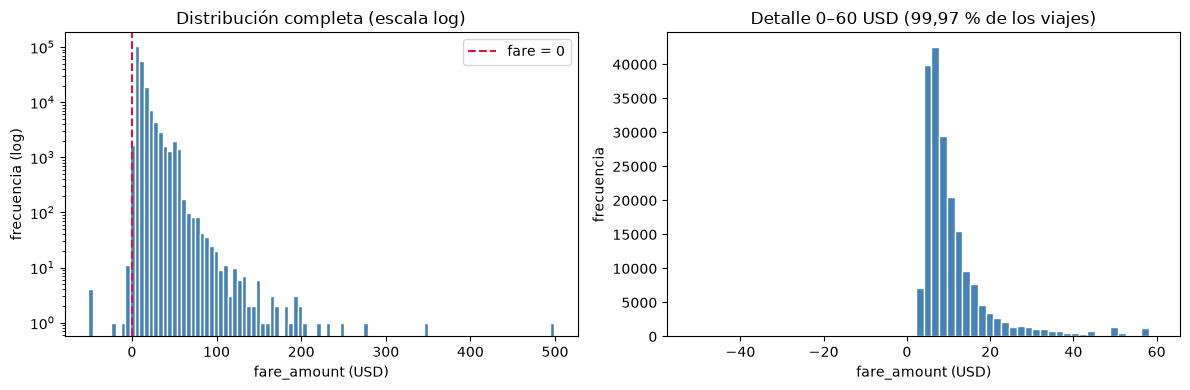

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw["fare_amount"], bins=100, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="fare = 0")
axes[0].set_yscale("log")
axes[0].set_title("Distribución completa (escala log)")
axes[0].set_xlabel("fare_amount (USD)"); axes[0].set_ylabel("frecuencia (log)")
axes[0].legend()

axes[1].hist(df_raw.loc[df_raw["fare_amount"] <= 60, "fare_amount"], bins=60,
             color="steelblue", edgecolor="white")
axes[1].set_title("Detalle 0–60 USD (99,97 % de los viajes)")
axes[1].set_xlabel("fare_amount (USD)"); axes[1].set_ylabel("frecuencia")
plt.tight_layout(); plt.show()

**Hallazgo:** la tarifa es fuertemente asimétrica a la derecha, con el grueso entre 5 y
15 USD y una cola larga; el detalle muestra un pico en la tarifa mínima (2,50 USD) y
negativos aislados. Recomendación: excluir las 22 tarifas no positivas (apartado de ingeniería de variables) y
modelar con métricas robustas (MAE). Presupuestar con la media (11,36 USD) sobreestima
el viaje típico (8,50 USD); para decisiones de precio conviene la mediana.

**b) Barras y pie de `passenger_count`.**

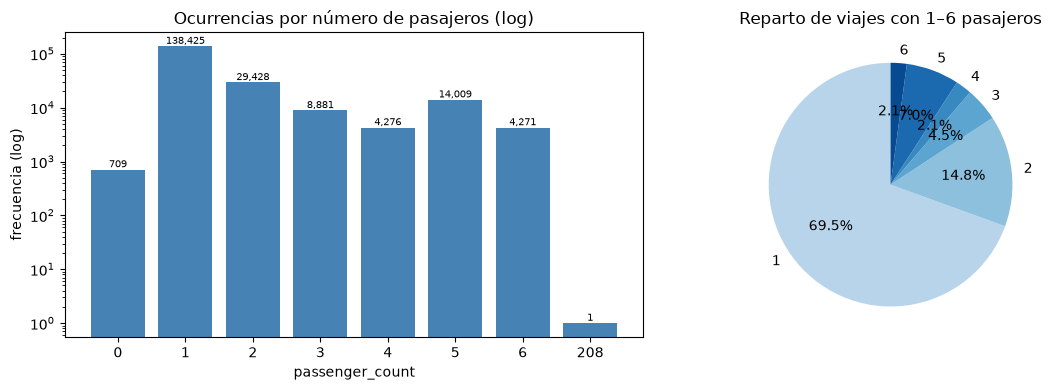

Resumen: 1 pasajero: 69.5 % | 2 pasajeros: 14.8 % | 0 o >6 (inválidos): 710


In [16]:
conteo = df_raw["passenger_count"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(conteo.index.astype(str), conteo.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("Ocurrencias por número de pasajeros (log)")
axes[0].set_xlabel("passenger_count"); axes[0].set_ylabel("frecuencia (log)")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7)

validos = df_raw.loc[df_raw["passenger_count"].between(1, 6), "passenger_count"].value_counts().sort_index()
axes[1].pie(validos.values, labels=validos.index, autopct="%1.1f%%", startangle=90,
            colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(validos))))
axes[1].set_title("Reparto de viajes con 1–6 pasajeros")
plt.tight_layout(); plt.show()

print("Resumen: 1 pasajero:", f"{100*validos.get(1,0)/validos.sum():.1f} %",
      "| 2 pasajeros:", f"{100*validos.get(2,0)/validos.sum():.1f} %",
      "| 0 o >6 (inválidos):", int(conteo.get(0,0) + conteo[conteo.index > 6].sum()))

**Hallazgo:** el 69,5 % de los viajes válidos lleva 1 pasajero y el 84,2 % lleva 1 o 2;
las ocupaciones 3–6 son minoritarias. Hay 710 registros imposibles (709 con 0 y uno con
208). Recomendación: tratar los códigos inválidos como faltantes (NaN) y la variable
como categórica de baja cardinalidad; no convertir 0 o 208 en categorías legítimas
porque el modelo aprendería de errores de captura.

**c) Dispersión `trip_distance_km` vs. `fare_amount` (datos limpios).**

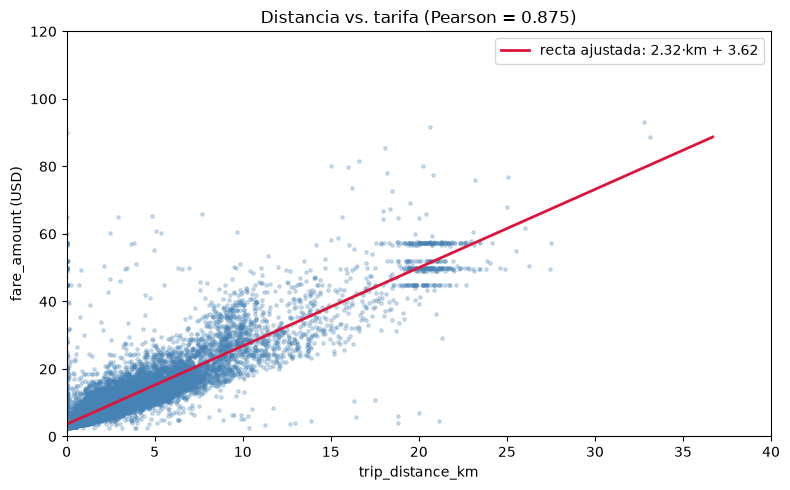

Pearson = 0.875 | Spearman = 0.847
Recta ajustada: 2.32 USD por km + 3.62 USD


In [17]:
muestra = df.sample(min(20000, len(df)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(muestra["trip_distance_km"], muestra["fare_amount"], s=6, alpha=0.25, color="steelblue")
coef = np.polyfit(df["trip_distance_km"], df["fare_amount"], 1)
x = np.linspace(0, df["trip_distance_km"].max(), 100)
ax.plot(x, np.polyval(coef, x), color="crimson", linewidth=2,
        label=f"recta ajustada: {coef[0]:.2f}·km + {coef[1]:.2f}")
ax.set_xlim(0, 40); ax.set_ylim(0, 120)
ax.set_xlabel("trip_distance_km"); ax.set_ylabel("fare_amount (USD)")
ax.set_title(f"Distancia vs. tarifa (Pearson = {df['trip_distance_km'].corr(df['fare_amount']):.3f})")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Pearson = {df['trip_distance_km'].corr(df['fare_amount']):.3f} | "
      f"Spearman = {df['trip_distance_km'].corr(df['fare_amount'], method='spearman'):.3f}")
print(f"Recta ajustada: {coef[0]:.2f} USD por km + {coef[1]:.2f} USD")

**Hallazgo:** relación lineal fuerte y positiva (Pearson 0,875, Spearman 0,847) con
heterocedasticidad: a mayor distancia, mayor dispersión. La recta ajustada ronda
2,32 USD/km con intercepto de 3,62 USD. Recomendación: la distancia es
la variable dominante y debe entrar escalada; la dispersión creciente a distancia fija
sugiere que hay estructura adicional (hora, zona, aeropuertos) que las variables
temporales del modelo pueden capturar parcialmente. Un modelo lineal con solo distancia
será un buen punto de partida, pero no el techo.

**d) Boxplots de `fare_amount` y `trip_distance_km`.**

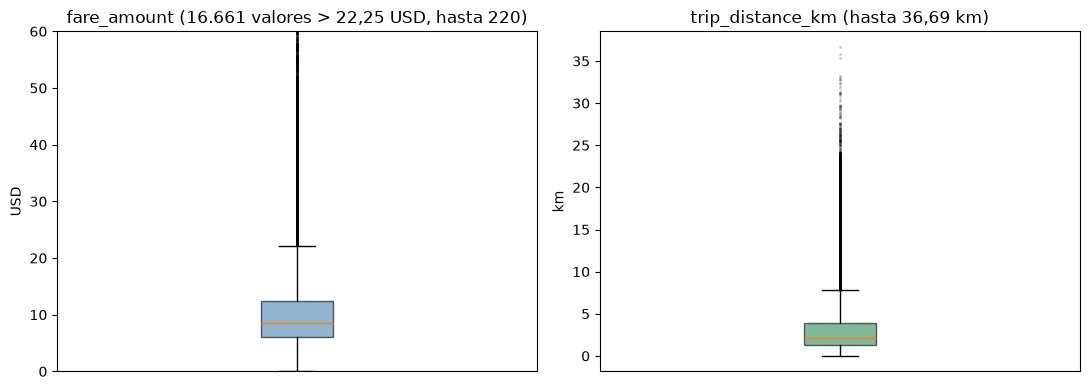

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot(df["fare_amount"], orientation="vertical", patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                flierprops=dict(marker=".", markersize=2, alpha=0.2))
axes[0].set_ylim(0, 60); axes[0].set_xticks([])
axes[0].set_title("fare_amount (16.661 valores > 22,25 USD, hasta 220)")
axes[0].set_ylabel("USD")

axes[1].boxplot(df["trip_distance_km"], orientation="vertical", patch_artist=True,
                boxprops=dict(facecolor="seagreen", alpha=0.6),
                flierprops=dict(marker=".", markersize=2, alpha=0.2))
axes[1].set_xticks([])
axes[1].set_title("trip_distance_km (hasta 36,69 km)")
axes[1].set_ylabel("km")
plt.tight_layout(); plt.show()

**Hallazgo:** la caja de la tarifa es estrecha (6–12,5 USD) y su cola es muy larga; la de
distancia también muestra muchos valores altos, pero continuos y sin saltos. 

**Decisión:**
no recortar ninguna de las dos (punto 7); usar un escalador robusto para que la cola
no domine y evaluar con MAE. Si el negocio exigiera estabilidad frente a valores
extremos, la alternativa sería *winsorizar* el target, pero eso cambia la definición de
la variable y no se justifica con 8,5 % de casos plausibles.

**e) Tarifa media y distancia media por hora del día.**

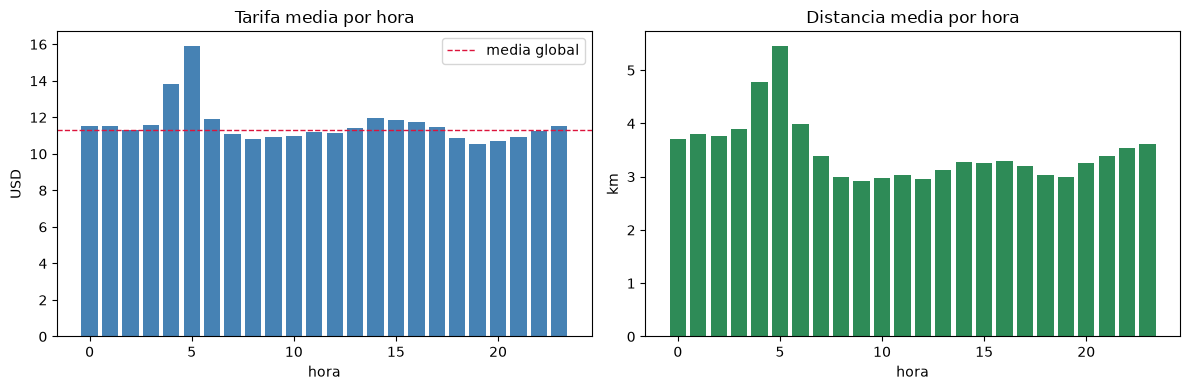

Hora con mayor tarifa media: 5 (15.91 USD, distancia media 5.46 km)
Hora con menor tarifa media: 19 (10.52 USD, distancia media 3.00 km)


In [19]:
por_hora = df.groupby("hour").agg(fare=("fare_amount", "mean"), dist=("trip_distance_km", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(por_hora.index, por_hora["fare"], color="steelblue")
axes[0].set_title("Tarifa media por hora"); axes[0].set_xlabel("hora"); axes[0].set_ylabel("USD")
axes[0].axhline(df["fare_amount"].mean(), color="crimson", linestyle="--", linewidth=1, label="media global")
axes[0].legend()

axes[1].bar(por_hora.index, por_hora["dist"], color="seagreen")
axes[1].set_title("Distancia media por hora"); axes[1].set_xlabel("hora"); axes[1].set_ylabel("km")
plt.tight_layout(); plt.show()

print("Hora con mayor tarifa media:", int(por_hora["fare"].idxmax()), f"({por_hora['fare'].max():.2f} USD, distancia media {por_hora.loc[por_hora['fare'].idxmax(), 'dist']:.2f} km)")
print("Hora con menor tarifa media:", int(por_hora["fare"].idxmin()), f"({por_hora['fare'].min():.2f} USD, distancia media {por_hora.loc[por_hora['fare'].idxmin(), 'dist']:.2f} km)")

**Hallazgo:** la tarifa media más alta ocurre a las 5:00 (15,91 USD) y la más baja a las
19:00 (10,52 USD), pero la distancia media a las 5:00 es 5,46 km frente a 3,00 km a las
19:00. 

**Interpretación:** el pico del amanecer refleja viajes más largos (aeropuertos),
no necesariamente *surge pricing*; el dataset no permite separar ambos efectos.

**Recomendación:** incluir `hour` en el modelo, pero no prometer que captura el *surge*;
para tarificación dinámica haría falta una fuente externa de demanda. Esta lectura evita
la conclusión fácil de "madrugada = tarifa alta".

### 9. Codificación de variables categóricas

Variables y cardinalidad real (después de la limpieza): `passenger_count` 6 niveles,
`hour` 24, `day_of_week` 7, `month` 12, `year` 7. Todas se codifican con **One-Hot
Encoding** (`handle_unknown="ignore"`, salida densa):

- **No hay orden natural:** ni la hora ni el día son magnitudes lineales para el precio.
  Codificarlas como ordinales (0–23) impondría que la diferencia entre las 23:00 y las
  00:00 es la misma que entre las 00:00 y las 01:00, y que la tarifa crece de forma
  monótona con el número de hora; ninguna de las dos cosas es cierta. Esto es
  especialmente dañino en **KNN**, que mide distancias, y en los modelos lineales, que
  asignarían un único coeficiente creciente a la hora.
- **Cardinalidad manejable:** el total de columnas tras el `ColumnTransformer` es 57
  (1 distancia + 56 indicadores), un tamaño razonable para 136.913 filas de
  entrenamiento. No se justifica un encoding más agresivo.
- **Alternativas descartadas:** *Label/Ordinal Encoding* introduce orden falso (razón
  anterior). *Binary Encoding* reduce dimensiones pero mantiene una estructura numérica
  arbitraria entre categorías. *Target Encoding* puede filtrar el target y con 24 niveles
  y datos de 2009–2015 es fácil sobreajustar; requeriría validación cruzada interna y no
  es el objetivo de esta fase.
- **Coste asumido:** 56 columnas binarias hacen que la distancia euclidiana de KNN sume
  muchas diferencias de indicadores poco informativos (maldición de la dimensionalidad).
  Se acepta porque se priorizó no inventar órdenes y porque Ridge/Lasso pueden
  amortiguar los indicadores inútiles (Lasso L1 los lleva a cero). El efecto en KNN se
  vigilará en las Fases 3–5. Una mejora futura sería codificación cíclica para `hour`
  (seno/coseno) o radios por distancia Haversine.

`drop="if_binary"` no cambia nada en este dataset (ninguna de estas variables tiene dos
niveles), pero se deja en el preprocesador común.

### 10. Escalado de variables numéricas

Solo `trip_distance_km` es numérica; las binarias One-Hot no se escalan (ya comparten el
rango 0–1 y escalarlas distorsionaría su interpretación). Para la distancia se compara el
comportamiento de los tres escaladores:

In [20]:
d = df["trip_distance_km"]
q1, q3 = d.quantile([0.25, 0.75])
print(f"media = {d.mean():.3f} | desviación = {d.std():.3f} | mediana = {d.median():.3f} | IQR = {q3-q1:.3f}")
print(f"asimetría = {d.skew():.2f}")
print(f"rango = {d.max()-d.min():.3f} | máximo = {d.max():.3f} | IQR/rango = {100*(q3-q1)/(d.max()-d.min()):.1f} %")
print("Si se usara Min-Max, el 50 % central de los viajes quedaría comprimido dentro de ese porcentaje del intervalo [0,1].")

media = 3.313 | desviación = 3.572 | mediana = 2.157 | IQR = 2.650
asimetría = 2.89
rango = 36.687 | máximo = 36.687 | IQR/rango = 7.2 %
Si se usara Min-Max, el 50 % central de los viajes quedaría comprimido dentro de ese porcentaje del intervalo [0,1].


**Decisión: `RobustScaler` para `trip_distance_km`.**

- **Contra Min-Max:** el IQR es solo el 7,2 % del rango. Min-Max comprimiría el 50 %
  central de los viajes en una franja minúscula de [0,1] y cualquier máximo futuro
  reescalaría todo el conjunto; es el más sensible a los valores extremos.
- **Contra StandardScaler:** usa media (3,31 km) y desviación (3,57 km), ambas infladas
  por la cola; centra en un valor que no es el viaje típico (la mediana es 2,16 km). Con
  asimetría 2,89, el centro y la escala estándar quedan "jalados" hacia los viajes
  largos.
- **A favor de RobustScaler:** centra en la mediana (2,16) y escala con el IQR (2,65),
  exactamente las mismas referencias con las que se detectaron y justificaron los
  outliers en el punto 7. El 50 % central de los viajes queda en un rango comparable
  para KNN y para la penalización de Ridge/Lasso. Es la opción coherente con la
  decisión de conservar los outliers plausibles.

Las binarias no se escalan: para KNN, cada indicador ya aporta a lo sumo 1 unidad de
diferencia y su varianza máxima es 0,25; para Ridge/Lasso, la penalización actúa igual
sobre coeficientes de variables 0/1 y su escala no depende de unidades físicas.

## Fase 2 - División de datos y pipelines

### 11. División train / validation / test (70/15/15)

**Para qué sirve cada conjunto:**

- **Train (70 %):** el modelo estima sus parámetros y *todas* las transformaciones
  (imputación, escalado, codificación) aprenden aquí.
- **Validation (15 %):** banco de pruebas para comparar modelos, detectar
  sobreajuste/subajuste y afinar hiperparámetros. Es un conjunto que "se gasta": cada vez
  que se toma una decisión mirándolo, su estimación se vuelve algo más optimista.
- **Test (15 %):** se reserva sin tocar hasta la Fase 6. Es la única estimación honesta
  de cómo se comportará el modelo con datos nuevos.

**¿Por qué no basta train/test?** Porque el conjunto de prueba quedaría contaminado
indirectamente: si se elige el modelo o el `k` mirando el desempeño en test, el test deja
de ser una muestra independiente y las métricas finales serán optimistas. Con validación
separada, todas las decisiones de las Fases 3–5 se toman en `val` y el test se evalúa una
sola vez. Con ~29.000 filas por conjunto, además, las métricas de validation son
suficientemente estables.

Se separa primero `X` de `y`, se dividen de forma aleatoria con `random_state=42` (no se
usa `stratify` porque el target es continuo) y se verifica que no haya intersecciones:

In [21]:
from sklearn.model_selection import train_test_split

numeric_cols = ["trip_distance_km"]
categorical_cols = ["passenger_count", "hour", "day_of_week", "month", "year"]
feature_cols = numeric_cols + categorical_cols

X = df[feature_cols].copy()
y = df["fare_amount"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")
print(f"reparto de filas: {100*len(X_train)/len(X):.1f} % / {100*len(X_val)/len(X):.1f} % / {100*len(X_test)/len(X):.1f} %")
print("intersección train∩val:", len(set(X_train.index) & set(X_val.index)),
      "| train∩test:", len(set(X_train.index) & set(X_test.index)),
      "| val∩test:", len(set(X_val.index) & set(X_test.index)))
assert len(X_train) + len(X_val) + len(X_test) == len(df)

# Se comparan únicamente train y validation; test queda reservado hasta la Fase 6.
resumen_split = pd.DataFrame({
    "n": [len(y_train), len(y_val)],
    "fare_medio": [y_train.mean(), y_val.mean()],
    "fare_mediano": [y_train.median(), y_val.median()],
    "dist_mediana": [X_train["trip_distance_km"].median(), X_val["trip_distance_km"].median()],
}, index=["train", "val"])
display(resumen_split.round(3))

train: (136913, 6) | val: (29338, 6) | test: (29339, 6)
reparto de filas: 70.0 % / 15.0 % / 15.0 %
intersección train∩val: 0 | train∩test: 0 | val∩test: 0


,n,fare_medio,fare_mediano,dist_mediana
train,136913,11.3080,8.5000,2.1610
val,29338,11.3540,8.5000,2.1680


Train y validación quedan casi idénticos en tarifa media/mediana y distancia mediana
(diferencias máximas inferiores al 2 %), lo que respalda la comparación de modelos sin
consultar la distribución de test. Las features se construyeron antes de
la división, pero son transformaciones deterministas fila a fila (Haversine, hora, día):
no usan promedios ni estadísticos de otras filas, por lo que no hay fuga posible. Los
aprendizajes (imputar, escalar, codificar) sí ocurren después, dentro del pipeline.

### 12. Pipeline de preprocesamiento con `ColumnTransformer`

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

def build_pipeline(model):
    # Pipeline completo (preprocesador + modelo) que reutilizará el modelado.
    return Pipeline([("preprocessor", preprocessor), ("model", model)])

preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
print("X_train transformado:", X_train_prep.shape)
print("columnas generadas:", list(preprocessor.get_feature_names_out()))

X_train transformado: (136913, 57)
columnas generadas: ['num__trip_distance_km', 'cat__passenger_count_1.0', 'cat__passenger_count_2.0', 'cat__passenger_count_3.0', 'cat__passenger_count_4.0', 'cat__passenger_count_5.0', 'cat__passenger_count_6.0', 'cat__hour_0.0', 'cat__hour_1.0', 'cat__hour_2.0', 'cat__hour_3.0', 'cat__hour_4.0', 'cat__hour_5.0', 'cat__hour_6.0', 'cat__hour_7.0', 'cat__hour_8.0', 'cat__hour_9.0', 'cat__hour_10.0', 'cat__hour_11.0', 'cat__hour_12.0', 'cat__hour_13.0', 'cat__hour_14.0', 'cat__hour_15.0', 'cat__hour_16.0', 'cat__hour_17.0', 'cat__hour_18.0', 'cat__hour_19.0', 'cat__hour_20.0', 'cat__hour_21.0', 'cat__hour_22.0', 'cat__hour_23.0', 'cat__day_of_week_0.0', 'cat__day_of_week_1.0', 'cat__day_of_week_2.0', 'cat__day_of_week_3.0', 'cat__day_of_week_4.0', 'cat__day_of_week_5.0', 'cat__day_of_week_6.0', 'cat__month_1.0', 'cat__month_2.0', 'cat__month_3.0', 'cat__month_4.0', 'cat__month_5.0', 'cat__month_6.0', 'cat__month_7.0', 'cat__month_8.0', 'cat__month_9.0',

El pipeline reproduce exactamente lo decidido en la Fase 1: mediana + RobustScaler para
la distancia, moda + One-Hot denso para las categóricas. Se prueba con un modelo
*benchmark* (`DummyRegressor`) para dejar una referencia de MAE/MSE/R² para comparar los modelos base:

In [23]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pipeline_dummy = build_pipeline(DummyRegressor(strategy="median")).fit(X_train, y_train)
for nombre, XX, yy in [("train", X_train, y_train), ("val", X_val, y_val)]:
    pred = pipeline_dummy.predict(XX)
    print(f"Dummy {nombre:5s} -> MAE {mean_absolute_error(yy, pred):.4f} | "
          f"MSE {mean_squared_error(yy, pred):.2f} | R2 {r2_score(yy, pred):.4f}")

Dummy train -> MAE 5.3426 | MSE 97.38 | R2 -0.0881
Dummy val   -> MAE 5.3930 | MSE 98.96 | R2 -0.0897


El `DummyRegressor` predice siempre la mediana de train (8,50 USD): obtiene MAE 5,34 en
train y 5,39 en validación, con R² negativo (peor que predecir la media). Es la cota
mínima que cualquier modelo real debe superar. El pipeline completo funciona de punta a
punta sin errores y sin cambiar la forma de los datos.

### 13. Verificación de ausencia de fuga de datos (data leakage)

Regla del taller: toda transformación que "aprende" (imputación, escalado, encoding) se
ajusta solo con `X_train`; sobre `X_val` y `X_test` se aplica únicamente `.transform()`.
En el código anterior esto se cumple porque `preprocessor.fit(X_train)` se ejecutó una
sola vez y las predicciones se generan con `pipeline.predict(XX)`, que internamente
transforma sin reajustar. La verificación explícita con números:

In [24]:
preprocessor.fit(X_train)  # ajuste exclusivo sobre train (repetido aquí para la evidencia)

num_step = preprocessor.named_transformers_["num"]
scaler = num_step.named_steps["scaler"]
imputer_num = num_step.named_steps["imputer"]
cat_step = preprocessor.named_transformers_["cat"]
imputer_cat = cat_step.named_steps["imputer"]
encoder = cat_step.named_steps["encoder"]

print("Estadístico del imputador numérico (mediana de train):", imputer_num.statistics_[0])
print("  mediana real en train:", X_train["trip_distance_km"].median())
print("  mediana en val:", X_val["trip_distance_km"].median())
print("Escalador: center =", scaler.center_[0], "| scale =", scaler.scale_[0])
print("  IQR real en train:", X_train["trip_distance_km"].quantile(.75) - X_train["trip_distance_km"].quantile(.25))
print("  IQR real en val:", X_val["trip_distance_km"].quantile(.75) - X_val["trip_distance_km"].quantile(.25))
print("Imputador categórico (moda de train):", dict(zip(categorical_cols, imputer_cat.statistics_)))
print("Categorías aprendidas por columna:", dict(zip(categorical_cols, [len(c) for c in encoder.categories_])))

no_vistos_val = sum(
    int((~X_val[col].dropna().isin(encoder.categories_[i])).sum())
    for i, col in enumerate(categorical_cols)
)
print("Valores de val no vistos en train:", no_vistos_val)

Z_train = preprocessor.transform(X_train)
Z_val = preprocessor.transform(X_val)
print("Mediana de la distancia escalada -> train:", round(float(np.median(Z_train[:, 0])), 6),
      "| val:", round(float(np.median(Z_val[:, 0])), 6))

center_antes = scaler.center_.copy()
_ = preprocessor.transform(X_val)
print("¿El centro del escalador cambió tras transformar val?", not np.array_equal(center_antes, scaler.center_))

Estadístico del imputador numérico (mediana de train): 2.1605696341684775
  mediana real en train: 2.1605696341684775
  mediana en val: 2.1683422154571783
Escalador: center = 2.1605696341684775 | scale = 2.654824972174546
  IQR real en train: 2.654824972174546
  IQR real en val: 2.680529010624242
Imputador categórico (moda de train): {'passenger_count': np.float64(1.0), 'hour': np.float64(19.0), 'day_of_week': np.float64(4.0), 'month': np.float64(5.0), 'year': np.float64(2012.0)}
Categorías aprendidas por columna: {'passenger_count': 6, 'hour': 24, 'day_of_week': 7, 'month': 12, 'year': 7}
Valores de val no vistos en train: 0
Mediana de la distancia escalada -> train: 0.0 | val: 0.002928
¿El centro del escalador cambió tras transformar val? False


**Evidencia cuantitativa:**

- El centro del `RobustScaler` es 2,160570 = mediana de **train** (la de val es 2,168342);
  la escala es 2,654825 = IQR de **train** (el de val es 2,680529). Si el ajuste hubiera
  usado val, sus valores estarían invertidos.
- La mediana de la distancia escalada es 0,000000 en train (centrada por construcción) y
  **+0,002928 en val**, justamente porque la transformación de val usa la mediana de
  train y no la suya. Una fuga produciría 0,000000 en ambos.
- Las 6+24+7+12+7 categorías del encoder provienen de train; no hay valores de validación
  fuera del vocabulario (0 no vistos), y `handle_unknown="ignore"` cubre ese riesgo en
  producción.
- El imputador categórico aprende la moda de train (1) y rellena los 485 NaN de
  `passenger_count` de train y los de validación con ese valor, no con la moda de cada
  conjunto.
- Transformar validación no modifica ningún atributo del `preprocessor` ajustado
  (`center_` no cambia), es decir, `.transform()` no reajusta nada.

Ninguna decisión de limpieza previa a la división (Haversine, hora, filtros) usa
estadísticos del conjunto completo, así que la única fuga posible estaría en el pipeline
y está descartada.

### Datos listos para modelar

| Elemento | Valor |
| --- | --- |
| Archivo limpio en memoria | `df` (195.590 filas, 7 columnas incluyendo target) |
| `X_train`, `y_train` | (136.913, 6) |
| `X_val`, `y_val` | (29.338, 6) |
| `X_test`, `y_test` | (29.339, 6) |
| `numeric_cols` | `["trip_distance_km"]` |
| `categorical_cols` | `["passenger_count", "hour", "day_of_week", "month", "year"]` |
| `preprocessor` | `ColumnTransformer`: mediana + `RobustScaler` para distancia; moda + `OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)` para categóricas. Salida: 57 columnas |
| Utilidad | `build_pipeline(model)` devuelve `Pipeline(preprocessor, model)` ajustable sobre `X_train` |
| Benchmark | `DummyRegressor(strategy="median")`: MAE val 5,393, MSE val 98,96, R² val −0,090 |
| Exclusiones | 4.410 filas (2,205 %): 22 tarifas ≤ 0, 4.368 fuera de la caja NYC, 20 tarifas >100 USD con distancia <1 km |
| Columnas excluidas de X | `Unnamed: 0`, `key`, las 4 coordenadas crudas; `fare_amount` es `y` |

**Modelos base:** `KNeighborsRegressor(n_neighbors=5, p=2)`, `Ridge(alpha=1.0)` y
`Lasso(alpha=0.1, max_iter=10_000)`, todos envueltos con `build_pipeline(...)`. Se
calculan MAE, MSE y R² en train y validation; el criterio principal de selección es el
MAE de validation junto con la brecha entre train y validation. El conjunto de test no
se usa hasta la Fase 6.

## Fase 3 - Modelado base de regresión

Se entrenan los tres modelos base sobre `X_train`: KNN Regressor,
Ridge (regularización L2) y Lasso (regularización L1). Cada estimador se integra con
una copia del preprocesador dentro de un `Pipeline`; así, imputación, escalamiento y
One-Hot se vuelven a ajustar exclusivamente con train. El conjunto de test permanece
intacto.

Los hiperparámetros iniciales definidos son: `k=5`, distancia
euclidiana (`p=2`), `alpha=1.0` para Ridge y `alpha=0.1` para Lasso. Se mide también
el tiempo como un *trade-off* práctico, especialmente relevante para KNN, que difiere
el mayor costo hasta la predicción.

In [25]:
from sklearn.base import clone
from sklearn.linear_model import Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import time

modelos_regresion = {
    "KNN": KNeighborsRegressor(n_neighbors=5, p=2, n_jobs=-1),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1, max_iter=10_000),
}

pipelines_regresion = {}
predicciones_regresion = {}
filas_metricas_reg = []

for nombre, estimador in modelos_regresion.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", estimador),
    ])

    inicio = time.perf_counter()
    pipeline.fit(X_train, y_train)
    segundos_fit = time.perf_counter() - inicio

    inicio = time.perf_counter()
    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    segundos_pred = time.perf_counter() - inicio

    pipelines_regresion[nombre] = pipeline
    predicciones_regresion[nombre] = {"train": pred_train, "val": pred_val}
    filas_metricas_reg.append({
        "Modelo": nombre,
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MSE_train": mean_squared_error(y_train, pred_train),
        "R2_train": r2_score(y_train, pred_train),
        "MAE_val": mean_absolute_error(y_val, pred_val),
        "MSE_val": mean_squared_error(y_val, pred_val),
        "R2_val": r2_score(y_val, pred_val),
        "seg_fit": segundos_fit,
        "seg_pred_train_val": segundos_pred,
    })
    print(f"{nombre}: completado")

metricas_regresion = pd.DataFrame(filas_metricas_reg).set_index("Modelo")
display(metricas_regresion.round(4))

KNN: completado
Ridge (L2): completado
Lasso (L1): completado


,MAE_train,MSE_train,R2_train,MAE_val,MSE_val,R2_val,seg_fit,seg_pred_train_val
Modelo,,,,,,,,
KNN,2.1682,14.9809,0.8326,2.7412,23.7626,0.7384,2.3081,49.4879
Ridge (L2),2.2215,19.4002,0.7832,2.2841,20.7462,0.7716,0.5177,0.2171
Lasso (L1),2.3176,20.3243,0.7729,2.3784,21.6847,0.7612,1.0602,0.2390


## Fase 5 - Métricas train/validation y diagnóstico de regresión

- **MAE** es el error absoluto típico en dólares y es fácil de comunicar al negocio.
- **MSE** penaliza de forma cuadrática los errores grandes, por lo que revela si las
  tarifas de la cola son especialmente difíciles.
- **R²** expresa qué fracción de la variabilidad de las tarifas explica el modelo;
  se interpreta junto con los errores, no como única evidencia.

La brecha entre train y validación se cuantifica sobre MAE. Una subida grande en
validación sugiere varianza/sobreajuste; desempeño pobre y parecido en ambos sugiere
sesgo/subajuste. El diagnóstico siguiente se basa solo en train y validación.

In [26]:
diagnostico_regresion = metricas_regresion.copy()
diagnostico_regresion["brecha_MAE_abs"] = (
    diagnostico_regresion["MAE_val"] - diagnostico_regresion["MAE_train"]
)
diagnostico_regresion["brecha_MAE_pct"] = (
    100 * diagnostico_regresion["brecha_MAE_abs"]
    / diagnostico_regresion["MAE_train"]
)

def diagnosticar_regresion(fila):
    if fila["brecha_MAE_pct"] > 10:
        return "Señal de sobreajuste: el MAE de validación aumenta más de 10 %."
    if fila["R2_train"] < 0.50 and fila["R2_val"] < 0.50:
        return "Señal de subajuste: R² bajo y similar en ambos conjuntos."
    return "Generalización estable: brecha train-validation reducida."

diagnostico_regresion["lectura"] = diagnostico_regresion.apply(
    diagnosticar_regresion, axis=1
)
display(diagnostico_regresion[["brecha_MAE_abs", "brecha_MAE_pct", "lectura"]].round(3))

ranking_regresion = metricas_regresion.sort_values(
    ["MAE_val", "R2_val"], ascending=[True, False]
)
modelo_ganador_regresion = ranking_regresion.index[0]
pipeline_ganador_regresion = pipelines_regresion[modelo_ganador_regresion]
print("Modelo ganador de regresión:", modelo_ganador_regresion)
display(ranking_regresion[["MAE_val", "MSE_val", "R2_val", "seg_fit", "seg_pred_train_val"]].round(4))

,brecha_MAE_abs,brecha_MAE_pct,lectura
Modelo,,,
KNN,0.5730,26.4260,Señal de sobreajuste: el MAE de validación aum...
Ridge (L2),0.0630,2.8140,Generalización estable: brecha train-validatio...
Lasso (L1),0.0610,2.6230,Generalización estable: brecha train-validatio...


Modelo ganador de regresión: Ridge (L2)


,MAE_val,MSE_val,R2_val,seg_fit,seg_pred_train_val
Modelo,,,,,
Ridge (L2),2.2841,20.7462,0.7716,0.5177,0.2171
Lasso (L1),2.3784,21.6847,0.7612,1.0602,0.2390
KNN,2.7412,23.7626,0.7384,2.3081,49.4879


### Selección del modelo de regresión y *trade-offs*

**Se selecciona Ridge (L2).** En validación logra el menor MAE (**2,2841 USD**),
el menor MSE (**20,7462**) y el mayor R² (**0,7716**). En términos de negocio, su
predicción se desvía aproximadamente 2,28 USD del precio real en un viaje típico y
explica 77,16 % de la variabilidad de las tarifas.

La decisión no depende solo del mejor valor puntual. Ridge es estable: su MAE pasa
de 2,2215 en train a 2,2841 en validación, una brecha de apenas **2,81 %**, por lo
que no hay señal importante de sobreajuste. Lasso también generaliza de forma
estable (brecha 2,62 %), pero su mayor MAE (2,3784) y menor R² (0,7612) muestran un
poco más de sesgo con `alpha=0.1`.

KNN obtiene mejor ajuste en train (MAE 2,1682; R² 0,8326), pero cae a MAE 2,7412 y
R² 0,7384 en validación: la brecha de MAE es **26,43 %**, evidencia de sobreajuste.
Además, la predicción es mucho más costosa que en los modelos lineales porque KNN
debe consultar los vecinos almacenados para cada observación nueva. Su flexibilidad
local no compensa ni el peor desempeño fuera de muestra ni el costo de inferencia.
Ridge ofrece aquí la mejor combinación
de precisión, estabilidad, velocidad e interpretabilidad y es el modelo que debe
optimizarse en la fase 7.

### Síntesis de modelado para la fase 9

En Uber, la relación dominante entre distancia y tarifa queda mejor capturada por
**Ridge**, lo que indica que una estructura aproximadamente lineal con contracción
L2 generaliza mejor que la frontera local de KNN. `RobustScaler` hace comparable la
distancia pese a los trayectos largos plausibles y permite que la penalización de
Ridge/Lasso sea coherente. KNN exhibe mayor varianza (brecha MAE 26,43 %) y un costo
de inferencia claramente mayor; cambiar `k` modificaría ese equilibrio: valores
pequeños aumentan varianza y valores grandes pueden aumentar sesgo. Lasso es estable,
pero su selección de
coeficientes introduce algo más de sesgo con el `alpha` inicial. Por eso Ridge es
el mejor compromiso base. La conclusión final debe contrastar esta selección con
test y con Ridge optimizado por CV, resultados de las fases posteriores.

## Fase 6 - Evaluación final en test

El conjunto de test no se tocó hasta ahora. Se evalúan los 3 modelos entrenados
(KNN, Ridge, Lasso) con las mismas métricas de la Fase 5, para obtener una
estimación honesta de generalización.

**Decisiones de código.**
- Se evalúan los pipelines ya entrenados en la Fase 3 (`pipelines_regresion`) sin volver a ajustarlos. Sobre `X_test` solo se llama a `.predict()`, que aplica internamente `.transform()` con los parámetros aprendidos en train (mediana del imputador, mediana e IQR del escalador, categorías del One-Hot). Así se garantiza que no hay fuga de datos: el test nunca influye en ningún parámetro.
- Se calculan las mismas métricas de la Fase 5 (MAE, MSE y R²) para que las tablas de validación y test sean directamente comparables. El MAE se expresa en dólares y es el más fácil de interpretar para el problema; el MSE penaliza más los errores grandes (útil para detectar si hay viajes con predicciones muy alejadas); y el R² indica qué proporción de la variabilidad de la tarifa explica el modelo.
- Se unen las métricas de validación y de test en una sola tabla (`comparativo_regresion`) porque la pregunta clave de esta fase no es cuál es el mejor número en test, sino si el ranking y el nivel de desempeño se sostienen respecto de validación.

In [27]:
filas_test_reg = []
for nombre, pipeline in pipelines_regresion.items():
    pred_test = pipeline.predict(X_test)
    filas_test_reg.append({
        "Modelo": nombre,
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "MSE_test": mean_squared_error(y_test, pred_test),
        "R2_test": r2_score(y_test, pred_test),
    })

metricas_test_regresion = pd.DataFrame(filas_test_reg).set_index("Modelo")

comparativo_regresion = metricas_regresion[["MAE_val", "MSE_val", "R2_val"]].join(
    metricas_test_regresion
)
display(comparativo_regresion.round(4))

,MAE_val,MSE_val,R2_val,MAE_test,MSE_test,R2_test
Modelo,,,,,,
KNN,2.7412,23.7626,0.7384,2.6730,22.0035,0.7523
Ridge (L2),2.2841,20.7462,0.7716,2.2182,19.0471,0.7856
Lasso (L1),2.3784,21.6847,0.7612,2.3123,19.9563,0.7753


El ranking se mantiene igual que en validación: Ridge (MAE 2,2182 USD, R² 0,7856), Lasso (2,3123; 0,7753) y KNN (2,6730; 0,7523). Los tres mejoran ligeramente en test (Ridge baja de 2,2841 a 2,2182 USD), lo que indica que la validación fue una guía confiable y no hubo sobreajuste a ese conjunto. Una diferencia grande en contra habría significado que validación no era representativa o que elegimos el modelo aprovechando su ruido.

Un MAE de 2,22 USD es cerca del 26 % de la tarifa mediana (8,50 USD), y el R² indica que el modelo explica alrededor del 79 % de la variabilidad. El MSE (19,05) es mucho mayor que el MAE al cuadrado (≈4,9), señal de que unos pocos viajes largos con tarifas altas generan errores grandes. Ridge supera a KNN porque la tarifa crece casi linealmente con la distancia, relación que un modelo lineal captura bien.

## Fase 7 - Validación cruzada y optimización de hiperparámetros

**¿Qué es K-Fold?** Se divide el conjunto de entrenamiento en K partes; se entrena K veces, dejando cada vez una parte distinta para validar y usando las otras K-1 para entrenar, y se promedian las K métricas. Es más confiable que un único split porque este depende de qué filas cayeron en cada lado por azar; con K-Fold cada observación valida una vez, y además se obtiene la variabilidad entre folds.


- **`pd.concat([X_train, X_val])`**: la CV ya separa train y validación en cada fold, y así hay más datos para entrenar. `X_test` no se toca.
- **Ridge y `alpha`**: es el ganador de la Fase 5, y alpha (fuerza de la penalización L2) es su único hiperparámetro relevante.
- **`np.logspace(-3, 3, 100)`**: alpha actúa por órdenes de magnitud, por lo que la escala logarítmica cubre todo el rango de forma uniforme.
- **`RandomizedSearchCV` (`n_iter=30`)**: prueba combinaciones al azar en vez de todas; es lo que pide el taller y escala mejor con más hiperparámetros.
- **`KFold(5, shuffle=True, random_state=...)`**: 5 folds equilibra confiabilidad y costo; `shuffle` evita depender del orden de las filas y la semilla da reproducibilidad.
- **`scoring="neg_mean_absolute_error"`**: sklearn maximiza, por eso el error va en negativo; se usa MAE por ser interpretable en dólares.
- **Pipeline completo dentro de la búsqueda**: en cada fold se reajusta todo el preprocesamiento solo con las filas de entrenamiento de ese fold, sin fuga de datos.

In [28]:
from sklearn.model_selection import RandomizedSearchCV, KFold

X_train_ext = pd.concat([X_train, X_val])
y_train_ext = pd.concat([y_train, y_val])
print("Tamaño del conjunto ampliado:", X_train_ext.shape)

# El modelo ganador de la Fase 5 fue Ridge (L2); se optimiza su alpha.
param_dist_reg = {"model__alpha": np.logspace(-3, 3, 100)}

search_regresion = RandomizedSearchCV(
    build_pipeline(Ridge()),
    param_distributions=param_dist_reg,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search_regresion.fit(X_train_ext, y_train_ext)

print("Mejores hiperparámetros:", search_regresion.best_params_)
print("Mejor MAE promedio en CV:", -search_regresion.best_score_)

modelo_final_regresion = search_regresion.best_estimator_

Tamaño del conjunto ampliado: (166251, 6)
Mejores hiperparámetros: {'model__alpha': np.float64(657.9332246575682)}
Mejor MAE promedio en CV: 2.229405038517237


Se eligió alpha ≈ 657,9, mucho mayor que el 1,0 inicial. Un alpha más alto encoge más los coeficientes, pero aquí el efecto práctico es mínimo: con más de 166.000 filas y 57 columnas después del One-Hot, el modelo tiene muy poca varianza que corregir. La gráfica (d) de la Fase 9 lo muestra: entre todos los alpha probados, el MAE de validación cruzada solo va de 2,2294 a 2,2340 USD, menos de un centavo de diferencia. El mejor valor quedó cerca del límite superior de la grilla (1000). Probar valores más altos podría bajar un poco más el MAE, pero por la forma de la curva la ganancia seguiría siendo de centavos.

In [29]:
pred_test_final_reg = modelo_final_regresion.predict(X_test)
metricas_final_regresion = {
    "MAE_test": mean_absolute_error(y_test, pred_test_final_reg),
    "MSE_test": mean_squared_error(y_test, pred_test_final_reg),
    "R2_test": r2_score(y_test, pred_test_final_reg),
}
print("Ridge optimizado en test:", metricas_final_regresion)
print("Ridge original (Fase 6) en test:", metricas_test_regresion.loc["Ridge (L2)"].to_dict())

Ridge optimizado en test: {'MAE_test': 2.2141044598732367, 'MSE_test': 19.050747767473652, 'R2_test': 0.785519364246105}
Ridge original (Fase 6) en test: {'MAE_test': 2.2182389940911906, 'MSE_test': 19.04710978786553, 'R2_test': 0.7855603220178804}


El modelo optimizado se evalúa sobre el mismo `X_test` y con las mismas métricas, así que la diferencia se debe solo al hiperparámetro. El MAE pasa de 2,2182 a 2,2141 USD (mejora de menos de medio centavo), el R² queda igual (0,7856) y el MSE es incluso un poco peor (19,0507 frente a 19,0471). La mejora es marginal y no cambia ninguna decisión: el alpha=1,0 inicial ya estaba bien.

## Fase 8 - Predicción sobre una muestra inventada

El viaje se construye como un `DataFrame` de una fila con las mismas variables y en el mismo orden que `feature_cols`, porque el `ColumnTransformer` las selecciona por nombre. Se predice con el Ridge optimizado, cuyo pipeline solo aplica el preprocesamiento aprendido en entrenamiento. Se eligió un viaje medio-largo en hora pico (12,5 km, viernes a las 6 p. m., mayo de 2015, 2 pasajeros) para ver si el modelo responde con una tarifa alta. Mayo de 2015 está dentro del rango de fechas del dataset, que termina en junio de 2015. Para juzgar la predicción se compara con dos referencias calculadas solo con train + validation.

In [30]:
viaje_inventado = pd.DataFrame([{
    "trip_distance_km": 12.5,   # viaje medio-largo
    "passenger_count": 2,
    "hour": 18,                 # hora pico de la tarde
    "day_of_week": 4,           # viernes
    "month": 5,                 # mayo, dentro del rango de fechas del dataset
    "year": 2015,
}])[feature_cols]

precio_predicho = modelo_final_regresion.predict(viaje_inventado)[0]
print(f"Tarifa predicha: {precio_predicho:.2f} USD")

# Referencias para juzgar la predicción, calculadas solo con train + validation.
coef_ref = np.polyfit(X_train_ext["trip_distance_km"], y_train_ext, 1)
print(f"Recta tarifa-distancia ({coef_ref[0]:.2f} USD/km + {coef_ref[1]:.2f}): "
      f"{np.polyval(coef_ref, 12.5):.2f} USD para 12,5 km")

similares = X_train_ext["trip_distance_km"].between(11.5, 13.5) & X_train_ext["year"].eq(2015)
tarifas_similares = y_train_ext[similares]
print(f"Viajes de 2015 entre 11,5 y 13,5 km: {int(similares.sum())} | "
      f"mediana {tarifas_similares.median():.2f} USD | "
      f"50 % central entre {tarifas_similares.quantile(.25):.2f} y {tarifas_similares.quantile(.75):.2f} USD")

Tarifa predicha: 34.60 USD
Recta tarifa-distancia (2.32 USD/km + 3.62): 32.62 USD para 12,5 km
Viajes de 2015 entre 11,5 y 13,5 km: 97 | mediana 35.50 USD | 50 % central entre 30.00 y 39.50 USD


La tarifa predicha es 34,60 USD y es coherente con el viaje inventado. La recta tarifa-distancia da 32,62 USD para 12,5 km, y los 97 viajes de 2015 con distancias entre 11,5 y 13,5 km tienen una tarifa mediana de 35,50 USD, con la mitad de ellos entre 30,00 y 39,50 USD. La predicción cae dentro de ese rango.

También tiene sentido que la predicción supere a la recta en unos 2 USD. La recta mezcla viajes de 2009 a 2015, y las tarifas del dataset subieron desde septiembre de 2012 (un viaje de 3 a 5 km pasó de una mediana de 10,50 a 13,00 USD). Como el viaje inventado es de 2015, es razonable que cueste más que el promedio histórico, y el modelo puede recoger esa diferencia con la variable `year`. La hora pico aporta poco, porque el dataset no tiene información directa de demanda ni de surge pricing. Los 2 pasajeros tampoco deberían cambiar mucho el precio, ya que se cobra por viaje y no por persona.

El resultado es una estimación del precio típico para ese tipo de viaje, no un precio exacto. El MAE en test es de 2,21 USD, y la ruta o el tráfico de ese día pueden mover la tarifa real varios dólares.

## Fase 9 - Conclusiones

El subplot 2×2 reúne las gráficas que mejor sustentan las conclusiones: (a) la relación entre distancia y tarifa, (b) si el desempeño de validación se sostuvo en test, (c) qué tan bien predice el modelo final en test y (d) cuánto depende el error de Ridge del valor de alpha.

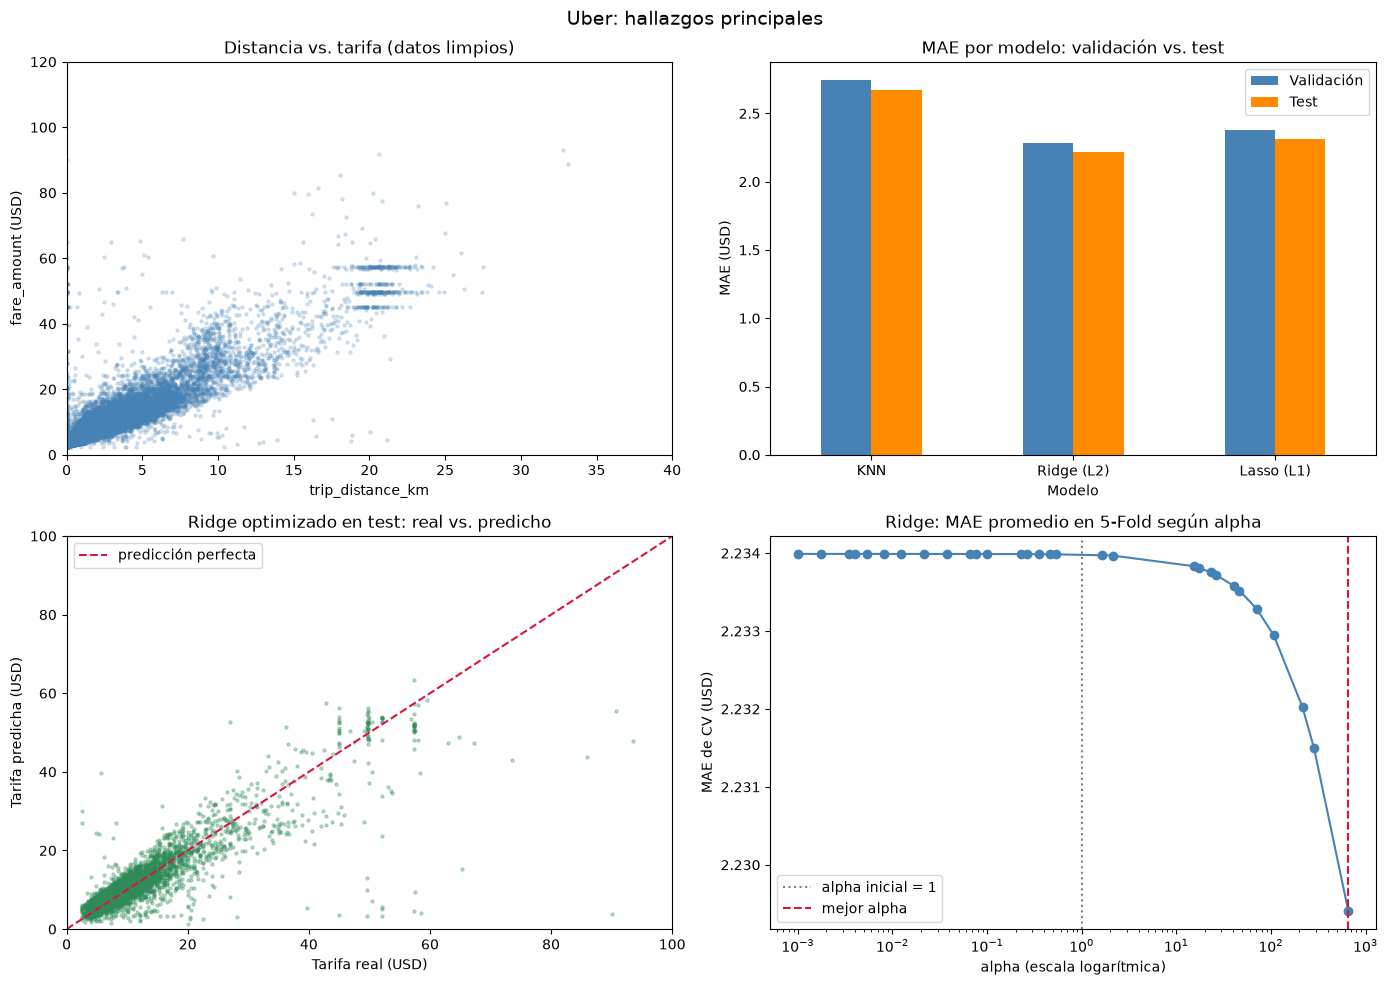

MAE de CV entre 2.2294 y 2.2340 USD en los 30 valores de alpha probados
Error absoluto en test: mediana 1.37 USD | MAE en viajes con tarifa > 22,25 USD: 7.81 USD | MAE en el resto: 1.71 USD


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# a) Relación entre distancia y tarifa en los datos limpios
muestra = df.sample(min(20000, len(df)), random_state=RANDOM_STATE)
axes[0, 0].scatter(muestra["trip_distance_km"], muestra["fare_amount"], s=5, alpha=0.2, color="steelblue")
axes[0, 0].set_xlim(0, 40); axes[0, 0].set_ylim(0, 120)
axes[0, 0].set_title("Distancia vs. tarifa (datos limpios)")
axes[0, 0].set_xlabel("trip_distance_km"); axes[0, 0].set_ylabel("fare_amount (USD)")

# b) MAE de cada modelo en validación y en test
comparativo_regresion[["MAE_val", "MAE_test"]].plot(
    kind="bar", rot=0, ax=axes[0, 1], color=["steelblue", "darkorange"]
)
axes[0, 1].set_title("MAE por modelo: validación vs. test")
axes[0, 1].set_xlabel("Modelo"); axes[0, 1].set_ylabel("MAE (USD)")
axes[0, 1].legend(["Validación", "Test"])

# c) Tarifa real vs. predicha por el modelo final en test
idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
axes[1, 0].scatter(y_test.to_numpy()[idx], pred_test_final_reg[idx], s=5, alpha=0.3, color="seagreen")
axes[1, 0].plot([0, 100], [0, 100], color="crimson", linestyle="--", label="predicción perfecta")
axes[1, 0].set_xlim(0, 100); axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_title("Ridge optimizado en test: real vs. predicho")
axes[1, 0].set_xlabel("Tarifa real (USD)"); axes[1, 0].set_ylabel("Tarifa predicha (USD)")
axes[1, 0].legend()

# d) MAE promedio de la validación cruzada según alpha
cv_reg = pd.DataFrame(search_regresion.cv_results_).sort_values("param_model__alpha")
axes[1, 1].plot(cv_reg["param_model__alpha"].astype(float), -cv_reg["mean_test_score"],
                marker="o", color="steelblue")
axes[1, 1].axvline(1.0, color="gray", linestyle=":", label="alpha inicial = 1")
axes[1, 1].axvline(search_regresion.best_params_["model__alpha"], color="crimson",
                   linestyle="--", label="mejor alpha")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Ridge: MAE promedio en 5-Fold según alpha")
axes[1, 1].set_xlabel("alpha (escala logarítmica)"); axes[1, 1].set_ylabel("MAE de CV (USD)")
axes[1, 1].legend()

fig.suptitle("Uber: hallazgos principales", fontsize=14)
plt.tight_layout(); plt.show()

print(f"MAE de CV entre {-cv_reg['mean_test_score'].max():.4f} y {-cv_reg['mean_test_score'].min():.4f} USD "
      f"en los {len(cv_reg)} valores de alpha probados")
errores = np.abs(y_test.to_numpy() - pred_test_final_reg)
print(f"Error absoluto en test: mediana {np.median(errores):.2f} USD | "
      f"MAE en viajes con tarifa > 22,25 USD: {errores[y_test.to_numpy() > 22.25].mean():.2f} USD | "
      f"MAE en el resto: {errores[y_test.to_numpy() <= 22.25].mean():.2f} USD")

### Qué muestran las gráficas

- (a) La tarifa crece casi en línea recta con la distancia (Pearson 0,875). Además se ve una franja horizontal entre 45 y 58 USD alrededor de los 20 km. Revisando las coordenadas, el 95 % de esos viajes empieza o termina en el aeropuerto JFK, y sus tarifas se concentran en unos pocos valores fijos (45 y 52 USD más peajes y recargos). Esos precios no dependen de la distancia.
- (b) Los tres modelos tienen un MAE en test un poco menor que en validación, y el orden se mantiene: Ridge, Lasso y KNN.
- (c) Hasta unos 25 USD, la mayoría de los puntos queda cerca de la diagonal. Por encima de ese valor el modelo tiende a quedarse corto, y aparecen columnas verticales cerca de 50 y 57 USD, que son otra vez las tarifas fijas de JFK. El error mediano en test es 1,37 USD, pero en los viajes de más de 22,25 USD el MAE sube a 7,81 USD, frente a 1,71 USD en el resto.
- (d) El MAE de validación cruzada casi no cambia con alpha: va de 2,2340 a 2,2294 USD. Toda la curva cabe en medio centavo.

### Datos y limpieza (fases 1 y 2)

La limpieza más determinante fue el filtro geográfico. 4.368 filas tenían coordenadas fuera de Nueva York, y en 3.779 de ellas el origen estaba en (0, 0). Si se hubieran conservado, la distancia Haversine habría dado cientos o miles de kilómetros para viajes de pocos dólares, y como la distancia es la variable más importante, el modelo habría aprendido una relación falsa. También fue necesario quitar las 22 tarifas menores o iguales a cero y los 20 viajes de más de 100 USD por menos de 1 km. En total se excluyó el 2,2 % de las filas. Los viajes largos y caros que sí eran plausibles (8,5 % de outliers según el IQR) se conservaron, y por eso se usó `RobustScaler` para la distancia.

### Modelado (fases 3 a 5)

Ridge fue el mejor modelo porque la tarifa depende casi linealmente de la distancia, y un modelo lineal captura esa relación con pocos parámetros y poca varianza. KNN con k=5 tuvo el mejor ajuste en train, pero su MAE subió 26 % en validación: con solo 5 vecinos, cada predicción depende mucho de viajes puntuales, lo que da poco sesgo y mucha varianza. Además, las 56 columnas One-Hot de hora, día, mes y año entran en la distancia entre viajes con el mismo peso que la distancia recorrida, y eso hace que los vecinos más cercanos no siempre sean los viajes más parecidos. KNN también fue el más lento para predecir, porque tiene que comparar cada viaje nuevo con los 136.913 de entrenamiento. Lasso con alpha=0,1 generalizó bien, pero encogió algunos coeficientes de más y quedó con un poco más de error que Ridge.

### Generalización y optimización (fases 6 a 8)

El test confirmó lo que mostró validación: Ridge tiene un MAE de 2,22 USD y un R² de 0,79, y el orden de los modelos no cambió. La búsqueda de alpha con validación cruzada solo mejoró el MAE en unas milésimas, así que el alpha inicial ya era adecuado. El viaje inventado recibió una tarifa coherente con viajes reales parecidos.

### Comparación con el problema de clasificación (Thyroid)

En los dos problemas ganó un modelo lineal regularizado (Ridge aquí, logística L2 en Thyroid) y KNN quedó de último, pero por razones distintas. Aquí la relación es casi lineal y hay datos de sobra: KNN se sobreajusta con k=5 y es lento. En Thyroid hay 254 pacientes de entrenamiento para 45 columnas, y KNN pierde porque todas las columnas pesan lo mismo en la distancia y, con tantas dimensiones, los pacientes "cercanos" no se parecen tanto. En ambos casos la optimización de hiperparámetros cambió poco.

La limpieza también pesó de forma distinta. En Uber lo decisivo fue quitar errores de captura, como las coordenadas imposibles. En Thyroid fue quitar una variable que anticipaba el resultado (`Response`). La mayor diferencia está en la confianza de los resultados: aquí validación y test tienen unos 29.000 viajes cada uno y las métricas son estables, mientras que en Thyroid tienen 55 pacientes y un solo paciente cambia el Recall en 6 puntos.

### Limitaciones y preguntas abiertas

- La calidad de las coordenadas es el punto débil del dataset. Además de las filas excluidas, quedan 1.963 viajes con distancia 0 y 3 tarifas por debajo de 2,50 USD que no se pudieron verificar.
- La distancia Haversine es en línea recta, no la ruta real, y no hay duración del viaje ni datos de tráfico.
- No hay información de demanda ni de surge pricing. La hora solo lo captura en parte.
- Los datos son de 2009 a 2015 e incluyen un cambio de tarifas en 2012. No representan los precios actuales.
- Las tarifas fijas al aeropuerto no siguen la relación con la distancia, y ahí es donde el modelo comete los errores más grandes.

Preguntas que quedan abiertas: ¿cuánto mejoraría el modelo con variables de ubicación, como la distancia a los aeropuertos o el barrio de origen y destino? ¿Una codificación cíclica de la hora, o un modelo no lineal como un árbol de decisión, capturaría mejor las tarifas fijas y los viajes largos? ¿Se mantendría el desempeño con datos más recientes?